## Тык

In [183]:
import skmob
from skmob.utils import utils, constants
from skmob.models.gravity import Gravity

import numpy as np
import pandas as pd
import geopandas as gpd

import osmnx as ox
from shapely.geometry import Polygon

url_tess = skmob.utils.constants.NY_COUNTIES_2011
tessellation = gpd.read_file(url_tess).rename(columns={'tile_id': 'tile_ID'})

fdf = skmob.FlowDataFrame.from_file(skmob.utils.constants.NY_FLOWS_2011,
                                        tessellation=tessellation,
                                        tile_id='tile_ID',
                                        sep=",")

                                     
tot_outflows = fdf[fdf['origin'] != fdf['destination']].groupby(by='origin', axis=0)[['flow']].sum().fillna(0) # Группировка по городам и подсчет миграции из каждого города
tessellation = tessellation.merge(tot_outflows, left_on='tile_ID', right_on='origin').rename(columns={'flow': constants.TOT_OUTFLOW}) # Merge с городами, населением и геометрией

In [18]:
import osmnx as ox
import geopandas as gpd
from tqdm import tqdm

# Загрузка данных (пример)
# tessellation = gpd.read_file('your_data.geojson')

# Определение тегов OSM
tags_config = {
    'clinic': {'amenity': 'clinic'},
    'theatre': {'amenity': 'theatre'},
    'museum': {'tourism': 'museum'},
    'park': {'leisure': 'park'}
}

# Функция для подсчета объектов
def count_pois(polygon, tag):
    try:
        # print(f'"{list(tag.keys())[0]}":"{list(tag.values())[0]}"')
        gdf = ox.features_from_polygon(
            polygon,
            tags=tag,
            # custom_filter=f'"{list(tag.keys())[0]}":"{list(tag.values())[0]}"'
        )
        return gdf[gdf.geometry.notnull()].shape[0]
    except:
        return 0

# Добавляем колонки для каждого типа объектов
for category in tags_config:
    tessellation[f'{category}_count'] = 0

# Обрабатываем все полигоны с визуализацией прогресса
for idx, row in tqdm(tessellation.iterrows(), total=len(tessellation)):
    geom = row.geometry
    for category, tag in tags_config.items():
        count = count_pois(geom, tag)
        tessellation.at[idx, f'{category}_count'] = count

# Результат
print(tessellation[['tile_ID', 'clinic_count', 'theatre_count', 'museum_count', 'park_count']].head())

 18%|█▊        | 11/62 [01:06<05:15,  6.19s/it]d:\programming\github\Migration-model\.venv\lib\site-packages\osmnx\features.py:690: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf.loc[:, "geometry"] = gdf["geometry"].make_valid()
 27%|██▋       | 17/62 [03:18<12:02, 16.06s/it]d:\programming\github\Migration-model\.venv\lib\site-packages\osmnx\features.py:690: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf.loc[:, "geometry"] = gdf["geometry"].make_valid()
100%|██████████| 62/62 [14:37<00:00, 14.16s/it]

  tile_ID  clinic_count  theatre_count  museum_count  park_count
0   36019             4              3            10          43
1   36101             8              3            11          56
2   36107             3              0             5          41
3   36059            94             23            54         940
4   36011             1              3             7          43


In [21]:
tessellation.to_csv('output.csv')

## Main

### Подготовка данных

In [184]:
from shapely.wkt import loads
import geopandas as gpd

tessellation = gpd.read_file('output.csv')
tessellation.rename(columns={'clinic_count': 'clinic', 'theatre_count': 'theatre', 'museum_count': 'museum', 'park_count': 'park'}, inplace=True)
tessellation = tessellation.set_index('index')
tessellation['geometry'] = tessellation['geometry'].apply(loads)
tessellation = gpd.GeoDataFrame(tessellation, geometry='geometry', crs="EPSG:4326")
tessellation[['population', 'tot_outflow', 'clinic', 'theatre','museum', 'park']] = tessellation[['population', 'tot_outflow', 'clinic', 'theatre','museum', 'park']].astype(int)
fdf = fdf[fdf['origin'] != fdf['destination']]
tessellation.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   tile_ID      62 non-null     object  
 1   population   62 non-null     int32   
 2   geometry     62 non-null     geometry
 3   tot_outflow  62 non-null     int32   
 4   clinic       62 non-null     int32   
 5   theatre      62 non-null     int32   
 6   museum       62 non-null     int32   
 7   park         62 non-null     int32   
dtypes: geometry(1), int32(6), object(1)
memory usage: 5.0+ KB


In [185]:
fdf.tessellation = tessellation
fdf.head(2), fdf.tessellation.head(2)

(   flow origin destination
 1     5  36001       36005
 2    29  36001       36007,
       tile_ID  population                                           geometry  \
 index                                                                          
 0       36019       81716  POLYGON ((-74.00667 44.88602, -74.02739 44.995...   
 1       36101       99145  POLYGON ((-77.09975 42.27422, -77.09966 42.272...   
 
        tot_outflow  clinic  theatre  museum  park  
 index                                              
 0             2472       4        3      10    43  
 1             9196       8        3      11    56  )

### Проверка моделей RF и GBR + оценка распределения данных

In [63]:
import pandas as pd

# Assuming fdf and tessellation are your DataFrames
# First, merge tessellation with fdf on 'origin'
fdf_origin = pd.merge(fdf, tessellation, left_on='origin', right_on='tile_ID', how='left', suffixes=('', '_o'))
fdf_origin = gpd.GeoDataFrame(fdf_origin)
# Then, merge tessellation with fdf_origin on 'destination'
fdf_full = pd.merge(fdf_origin, tessellation, left_on='destination', right_on='tile_ID', how='left', suffixes=('_o', '_d'))
fdf_full
# Drop the unnecessary index columns after merging
fdf_full.drop(columns=['tile_ID_o', 'tile_ID_d'], inplace=True)

# # Now fdf_full contains the columns from tessellation for both origin and destination
train_data = fdf_full[fdf_full['origin'] != fdf_full['destination']]


In [158]:
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from migration.metrics import RMSE, MRE, MLogRatio, common_part_of_commuters, common_part_of_commuters_accuracy

def train_and_save_model(train_data: dict, 
                         test_data: dict = None, 
                         label: str = 'total_pop_flow',
                         features: list = ['clinic', 'theatre', 'museum', 'park'],
                         model_path: str = "models/RF/rf_model.joblib", 
                         save_model: bool = False) -> tuple:
    
    """Обучение модели и сохранение результатов"""
    
    # Check if input data is a dictionary and concatenate if necessary
    if isinstance(train_data, dict):
        all_train_data = pd.concat(train_data.values())
    else:
        all_train_data = train_data
    
    # Подготовка фичей и таргета
    train_labels = np.log(np.array(all_train_data[label]))
    train_features = np.array(all_train_data[features])
    
    # Обучение модели
    rf = RandomForestRegressor(n_estimators=1000, n_jobs=-1, verbose=1)
    rf.fit(train_features, train_labels)

    from pathlib import Path
    Path("models/RF").mkdir(parents=True, exist_ok=True)
    
    # Сохранение модели
    if save_model:
        joblib.dump(rf, model_path)
    
    # Оценка качества
    if isinstance(test_data, dict): 
        results = evaluate_model(rf, test_data, label, features)
        return rf, results
    else:
        return rf

def evaluate_model(model, 
                   test_data: dict, 
                   label: str = 'total_pop_flow', 
                   features: list = ['clinic', 'theatre', 'museum', 'park']) -> pd.DataFrame:
    
    """Оценка модели на тестовых данных"""
    res = {}
    
    for key, df in test_data.items():
        test_labels = np.array(df[label])
        test_features = np.array(df[features])
        predictions = np.exp(model.predict(test_features))

        res[key] = [
            common_part_of_commuters(test_labels, predictions),
            common_part_of_commuters_accuracy(test_labels, predictions),
            RMSE(test_labels, predictions),
            MRE(test_labels, predictions),
            MLogRatio(test_labels, predictions),
        ]
    
    return pd.DataFrame(res, index=[['Random Forest'] * 5, ['CPC', 'ACC', 'RMSE', 'RE', 'LR']])

import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import joblib
from pathlib import Path

def train_and_save_model_GBR(
    train_data: dict,
    test_data: dict = None,
    label: str = 'total_pop_flow',
    features: list = ['population_o', 'clinic_o', 'theatre_o', 'museum_o', 'park_o',
                      'population_d', 'clinic_d', 'theatre_d', 'museum_d', 'park_d'],
    model_path: str = "models/GB/gb_model.joblib",
    save_model: bool = False
) -> tuple:
    
    """Обучение модели и сохранение результатов"""
    
    # Объединение данных
    if isinstance(train_data, dict):
        all_train_data = pd.concat(train_data.values())
    else:
        all_train_data = train_data
    
    # Преобразование Бокса-Кокса для нормализации
    pt = PowerTransformer(method='box-cox')
    y_raw = np.array(all_train_data[label]) + 1e-6  # Избегаем нулей
    y_transformed = pt.fit_transform(y_raw.reshape(-1, 1)).flatten()
    
    # Фичи
    X = np.array(all_train_data[features])
    
    # Обучение Gradient Boosting с Poisson-функцией потерь
    model = GradientBoostingRegressor(
        # loss='',          # Функция потерь для счетных данных
        n_estimators=500,        # Уменьшено для скорости
        max_depth=5,             # Регуляризация
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X, y_transformed)
    
    # Сохранение модели и преобразователя
    Path("models/GB").mkdir(parents=True, exist_ok=True)
    if save_model:
        joblib.dump(model, model_path)
        joblib.dump(pt, "models/GB/power_transformer.joblib")
    
    # Оценка на тестовых данных (если есть)
    if isinstance(test_data, dict):
        all_test_data = pd.concat(test_data.values())
        X_test = np.array(all_test_data[features])
        y_test_raw = np.array(all_test_data[label]) + 1e-6
        y_test_transformed = pt.transform(y_test_raw.reshape(-1, 1)).flatten()
        
        pred_test = model.predict(X_test)
        mse = mean_squared_error(y_test_transformed, pred_test)
        print(f"Test MSE: {mse}")
        
        return model, pt, mse
    else:
        return model, pt

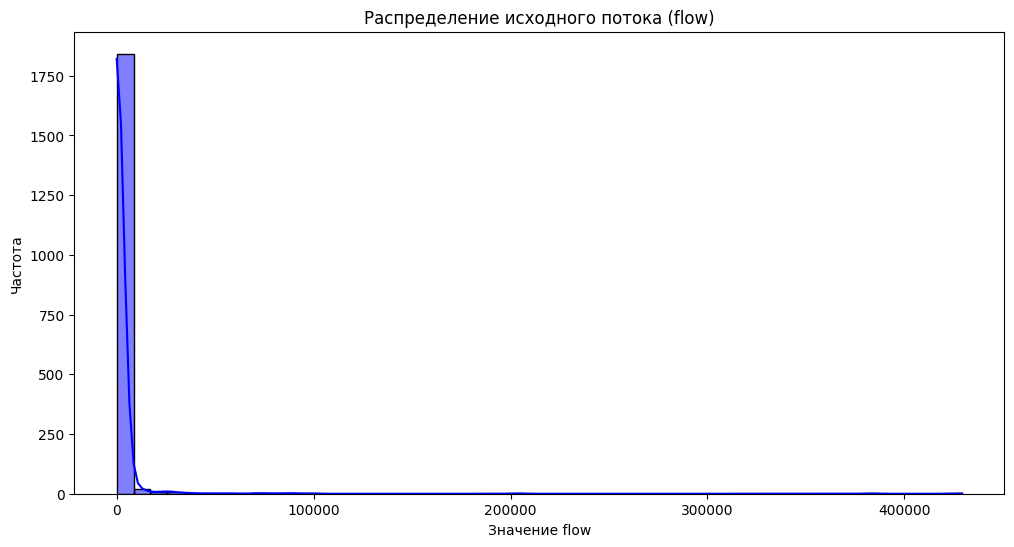

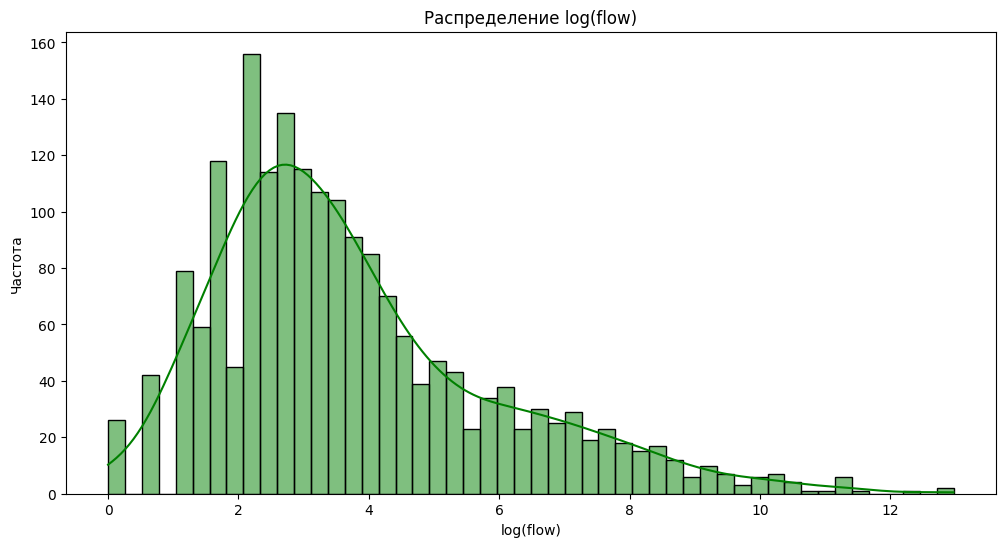

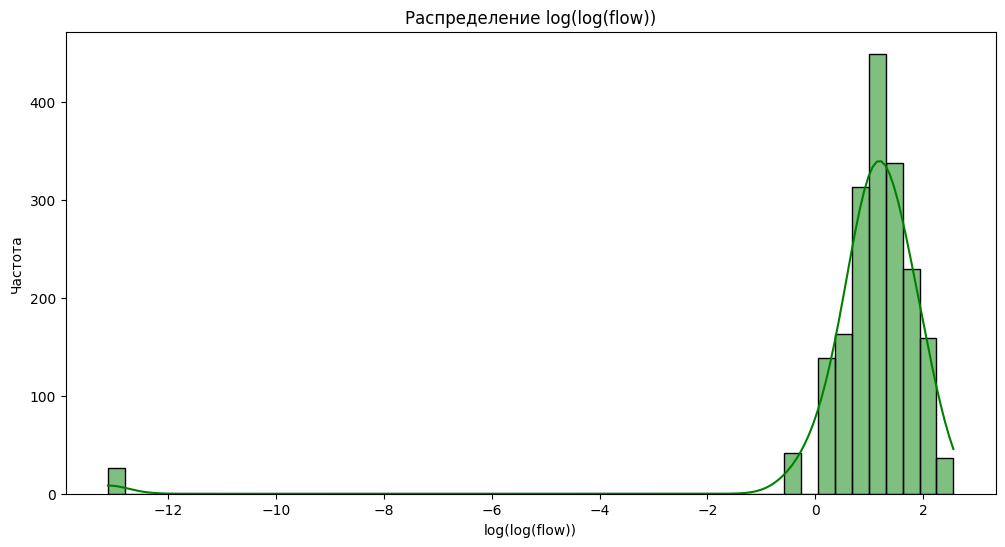

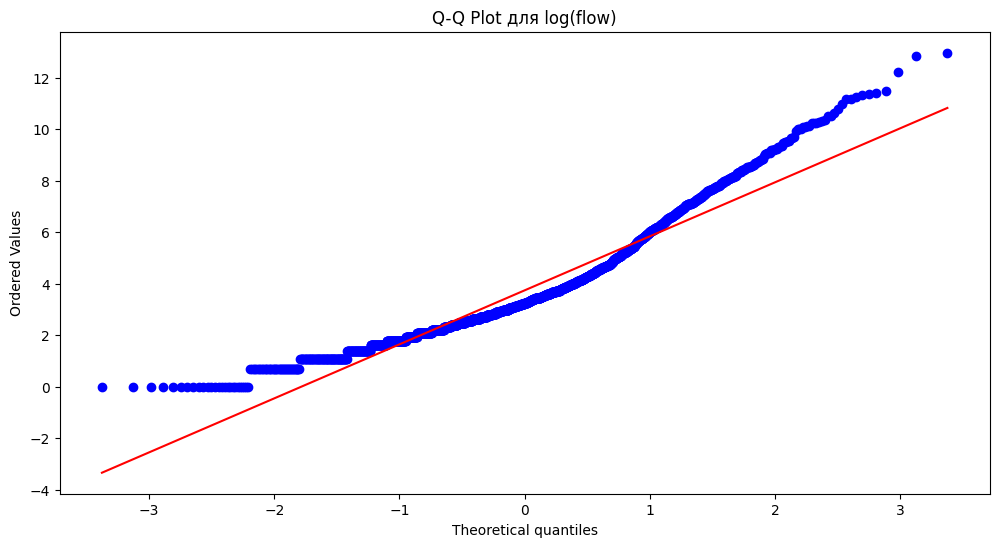

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Гистограмма и KDE
plt.figure(figsize=(12, 6))
sns.histplot(train_data['flow'], kde=True, bins=50, color='blue')
plt.title('Распределение исходного потока (flow)')
plt.xlabel('Значение flow')
plt.ylabel('Частота')
plt.show()

# Добавление константы для избежания log(0)
train_data['log_flow'] = np.log(train_data['flow'] + 1e-6)  # или +1
train_data['log_log_flow'] = np.log(train_data['log_flow'] + 1e-6)  # или +1

# Гистограмма и KDE
plt.figure(figsize=(12, 6))
sns.histplot(train_data['log_flow'], kde=True, bins=50, color='green')
plt.title('Распределение log(flow)')
plt.xlabel('log(flow)')
plt.ylabel('Частота')
plt.show()

# Гистограмма и KDE
plt.figure(figsize=(12, 6))
sns.histplot(train_data['log_log_flow'], kde=True, bins=50, color='green')
plt.title('Распределение log(log(flow))')
plt.xlabel('log(log(flow))')
plt.ylabel('Частота')
plt.show()

from scipy import stats

# Q-Q Plot для log(flow)
plt.figure(figsize=(12, 6))
stats.probplot(train_data['log_flow'], dist="norm", plot=plt)
plt.title('Q-Q Plot для log(flow)')
plt.show()

# # Тест Шапиро-Уилка (для n < 5000)
# shapiro_test = stats.shapiro(train_data['log_flow'].sample(min(5000, len(train_data))))
# print(f"Shapiro-Wilk p-value: {shapiro_test.pvalue}")

# # Тест Колмогорова-Смирнова
# kstest = stats.kstest(train_data['log_flow'], 'norm', 
#                      args=(train_data['log_flow'].mean(), train_data['log_flow'].std()))
# print(f"Kolmogorov-Smirnov p-value: {kstest.pvalue}")

# # Остатки
# residuals = log_pred - train_data['flow']  # train_labels = log(flow)

# # Гистограмма остатков
# plt.figure(figsize=(12, 6))
# sns.histplot(residuals, kde=True, bins=50, color='red')
# plt.title('Распределение остатков модели')
# plt.xlabel('Ошибка (log-шкала)')
# plt.ylabel('Частота')
# plt.show()

# # Q-Q Plot остатков
# stats.probplot(residuals, dist="norm", plot=plt)
# plt.title('Q-Q Plot остатков')
# plt.show()

In [161]:
rf = train_and_save_model(train_data=train_data, label='flow', features=['population_o','clinic_o','theatre_o','museum_o','park_o','population_d','clinic_d','theatre_d','museum_d','park_d'])

gbr, pt = train_and_save_model_GBR(train_data=train_data, label='flow', features=['population_o','clinic_o','theatre_o','museum_o','park_o','population_d','clinic_d','theatre_d','museum_d','park_d'])

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    1.6s finished


In [163]:
pred_transformed = gbr.predict(np.array(train_data[['population_o','clinic_o','theatre_o','museum_o','park_o','population_d','clinic_d','theatre_d','museum_d','park_d']]))
pred_flow = pt.inverse_transform(pred_transformed.reshape(-1, 1)).flatten() - 1e-6

# Суммарный поток
print(f"Origin flow:    {train_data.groupby('origin')['flow'].sum().sum()}")
print(f"Predicted flow: {np.sum(pred_flow)}")

Origin flow:    2978046
Predicted flow: 2451489.4526390727


In [164]:
train_data.groupby('origin')['flow'].sum().sum() - np.sum(pred_flow)

526556.5473609273

In [153]:
log_pred = rf.predict(train_data[['population_o','clinic_o','theatre_o','museum_o','park_o','population_d','clinic_d','theatre_d','museum_d','park_d']])
pred = np.round(np.exp(log_pred + 0.5 * np.var(log_pred - np.log(train_data['flow']))))
pred

d:\programming\github\Migration-model\.venv\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 1000 out of 1000 | elapsed:    0.2s finished


array([11., 63., 25., ..., 19., 54., 12.])

In [154]:
train_data = train_data.reset_index(drop=True)
final_df = pd.concat([train_data[['origin', 'destination', 'flow', 'geometry_o', 'geometry_d']], pd.DataFrame(pred, columns=['pred'])], axis=1)
final_df

,origin,destination,flow,geometry_o,geometry_d,pred
0,36001,36005,5,"POLYGON ((-73.93367 42.76071, -73.8096 42.7750...","POLYGON ((-73.78352 40.88103, -73.74806 40.871...",11.0
1,36001,36007,29,"POLYGON ((-73.93367 42.76071, -73.8096 42.7750...","POLYGON ((-75.85039 42.32773, -75.84379 42.259...",63.0
2,36001,36017,11,"POLYGON ((-73.93367 42.76071, -73.8096 42.7750...","POLYGON ((-75.68409 42.73415, -75.42867 42.745...",25.0
3,36001,36019,30,"POLYGON ((-73.93367 42.76071, -73.8096 42.7750...","POLYGON ((-74.00667 44.88602, -74.02739 44.995...",29.0
4,36001,36021,728,"POLYGON ((-73.93367 42.76071, -73.8096 42.7750...","POLYGON ((-73.75567 42.02348, -73.90778 42.079...",479.0
...,...,...,...,...,...,...
1887,36123,36105,6,"POLYGON ((-77.35736 42.66916, -77.35441 42.697...","POLYGON ((-74.98383 41.50537, -74.98764 41.508...",12.0
1888,36123,36107,57,"POLYGON ((-77.35736 42.66916, -77.35441 42.697...","POLYGON ((-76.25015 42.29668, -76.24914 42.302...",52.0
1889,36123,36109,4,"POLYGON ((-77.35736 42.66916, -77.35441 42.697...","POLYGON ((-76.53835 42.28176, -76.69141 42.284...",19.0
1890,36123,36117,63,"POLYGON ((-77.35736 42.66916, -77.35441 42.697...","POLYGON ((-77.37331 43.12341, -77.37622 43.345...",54.0


Origin flow:    2978046
Predic flow:    2306018.0


<Axes: >

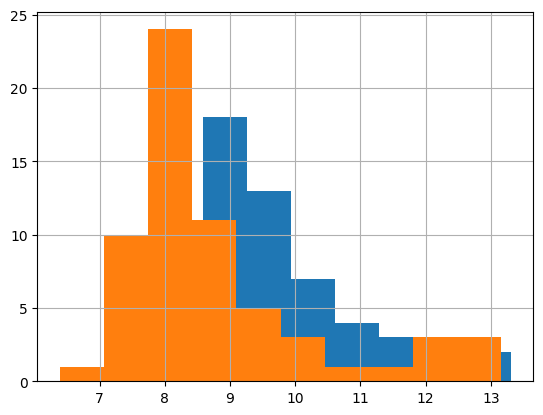

In [155]:
print(f"Origin flow:    {final_df.groupby('origin')['flow'].sum().sum()}")
print(f"Predic flow:    {final_df.groupby('origin')['pred'].sum().sum()}")
np.log(final_df.groupby('origin')['flow'].sum()).hist()
np.log(final_df.groupby('origin')['pred'].sum()).hist()

### Использование SK Mobility

In [186]:
import skmob
from skmob.utils import utils, constants
from skmob.models.gravity import Gravity

import numpy as np
import pandas as pd
import geopandas as gpd

In [187]:
fdf.tessellation.describe()

,population,tot_outflow,clinic,theatre,museum,park
count,6.200000e+01,62.000000,62.000000,62.000000,62.000000,62.000000
mean,3.144922e+05,48033.000000,19.774194,10.725806,12.629032,134.564516
std,5.382056e+05,111119.020077,41.379657,24.287330,15.115114,194.814550
min,4.826000e+03,709.000000,0.000000,0.000000,1.000000,4.000000
25%,5.103925e+04,6623.000000,1.250000,2.000000,5.000000,32.250000
50%,9.106950e+04,11337.000000,5.000000,4.000000,9.000000,49.000000
75%,2.309242e+05,31033.250000,18.250000,12.000000,15.750000,126.000000
max,2.540822e+06,599902.000000,228.000000,184.000000,93.000000,940.000000


In [188]:
gravity_singly = Gravity(gravity_type='singly constrained', origin_exp=0.5, destination_exp=2.0, deterrence_func_args=[-4.0])
print(gravity_singly)

Gravity(name="Gravity model", deterrence_func_type="power_law", deterrence_func_args=[-4.0], origin_exp=0.5, destination_exp=2.0, gravity_type="singly constrained")


In [189]:
gravity_singly.fit(fdf, relevance_column='museum')
print(gravity_singly)

Gravity(name="Gravity model", deterrence_func_type="power_law", deterrence_func_args=[-2.5537008255340323], origin_exp=1.0, destination_exp=1.269413768759818, gravity_type="singly constrained")


In [ ]:
tesscopy = tessellation.copy(deep=True)
# tesscopy.loc[tesscopy['tile_ID'] == '36061', 'museum'] = 3

In [198]:
fdfcopy.tessellation.loc[fdfcopy.tessellation['tile_ID'] == '36061']['museum'], fdf.tessellation.loc[fdfcopy.tessellation['tile_ID'] == '36061']['museum'], 

(index
 45    93
 Name: museum, dtype: int32,
 index
 45    93
 Name: museum, dtype: int32)

In [199]:
np.random.seed(0)

tessellation.loc[tessellation['tile_ID'] == '36061', 'museum'] = 93

synth_fdf = gravity_singly.generate(tessellation,
                                   tile_id_column='tile_ID',
                                   tot_outflows_column='tot_outflow',
                                   relevance_column= 'museum',
                                   out_format='flows')

tessellation.loc[tessellation['tile_ID'] == '36061', 'museum'] = 3

synth_fdf2 = gravity_singly.generate(tessellation,
                                   tile_id_column='tile_ID',
                                   tot_outflows_column='tot_outflow',
                                   relevance_column= 'museum',
                                   out_format='flows')

100%|██████████| 62/62 [00:00<00:00, 14800.62it/s]
d:\programming\github\Migration-model\.venv\lib\site-packages\skmob\models\gravity.py:43: RuntimeWarning: divide by zero encountered in power
  return np.power(x, exponent)
100%|██████████| 62/62 [00:00<?, ?it/s]
d:\programming\github\Migration-model\.venv\lib\site-packages\skmob\models\gravity.py:43: RuntimeWarning: divide by zero encountered in power
  return np.power(x, exponent)


In [209]:
inflow = synth_fdf.groupby('destination')['flow'].sum().rename('inflow')
outflow = synth_fdf.groupby('origin')['flow'].sum().rename('outflow')

synth_fdf.tessellation = synth_fdf.tessellation.merge(
    inflow, 
    left_on='tile_ID', 
    right_index=True, 
    how='left'
).merge(
    outflow, 
    left_on='tile_ID', 
    right_index=True, 
    how='left'
).fillna(0)

synth_fdf.tessellation['inflow'] = synth_fdf.tessellation['inflow'].astype(int)
synth_fdf.tessellation['outflow'] = synth_fdf.tessellation['outflow'].astype(int)

In [ ]:
import folium
from folium.features import GeoJson
from folium.plugins import PolyLineTextPath
from shapely.geometry import LineString
import branca.colormap as cm

threshold = synth_fdf['flow'].quantile(0.95)
top_flows = synth_fdf[synth_fdf['flow'] >= threshold]
top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))

# 1. Создаем базовую карту
m = synth_fdf.tessellation.explore(
    column='museum', 
    tiles='CartoDB dark_matter',
    cmap='viridis',
    tooltip=['tile_ID', 'museum', 'inflow', 'outflow'],
    name='Полигоны'
)

# 2. Настраиваем цветовую шкалу
colormap = cm.LinearColormap(
    ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15'],
    vmin=top_flows['flow'].min(),
    vmax=top_flows['flow'].max(),
    caption='Интенсивность миграции'
).add_to(m)

# 3. Добавляем линии со стрелками
lines_layer = folium.FeatureGroup(name='Топ-10% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf.tessellation[synth_fdf.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf.tessellation[synth_fdf.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Получаем координаты для линии (центроиды)
    line_coords = [
        [origin_geom.centroid.y, origin_geom.centroid.x],
        [dest_geom.centroid.y, dest_geom.centroid.x]
    ]
    
    # Создаем линию
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.8
    )
    
    # Добавляем подсказку
    line.add_child(
        folium.Tooltip(f"From {row['origin']} to {row['destination']}<br>Flow: {row['flow']:.1f}")
    )
    
    line.add_to(lines_layer)

# 4. Добавляем элементы управления
folium.LayerControl().add_to(m)
m.add_child(colormap)

# 5. Отображаем карту
m.save('map one.html')
m

C:\Users\Local\AppData\Local\Temp\ipykernel_5108\2641580592.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))


In [230]:
import folium
from folium.plugins import PolyLineTextPath
import branca.colormap as cm
from mapclassify import NaturalBreaks  # Добавили классификатор

# Рассчитываем net_flow для полигонов
synth_fdf.tessellation['net_flow'] = synth_fdf.tessellation['inflow'] - synth_fdf.tessellation['outflow']

# 1. Создаем базовую карту со светлой подложкой и новой схемой окраски
m = synth_fdf.tessellation.explore(
    column='net_flow',  # Изменили на net_flow
    scheme='NaturalBreaks',  # Используем натуральные разрывы Jenks
    k=5,  # Количество классов
    tiles='CartoDB positron',  # Светлая подложка
    cmap='RdYlGn',  # Красно-желто-зеленая палитра
    tooltip=[
        'tile_ID','inflow', 'outflow', 'net_flow', 
    ],
    name='Баланс миграции',
)

# 2. Настраиваем цветовую шкалу для миграционных потоков с квантелями
# Рассчитываем квантели для потоков
quantiles = top_flows['flow'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()

colormap = cm.StepColormap(
    ['#fef0d9', '#fdcc8a', '#fc8d59', '#e34a33', '#b30000'],
    index=quantiles,  # Используем квантели как точки разрыва
    caption='Интенсивность миграции (топ 5% потоков)'
).add_to(m)

# 3. Модифицируем линии миграции
lines_layer = folium.FeatureGroup(name='Топ-5% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf.tessellation[synth_fdf.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf.tessellation[synth_fdf.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Соединяем границы полигонов вместо центроидов
    origin_point = origin_geom.representative_point()
    dest_point = dest_geom.representative_point()
    
    line_coords = [
        [origin_point.y, origin_point.x],
        [dest_point.y, dest_point.x]
    ]
    
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.9
    )
    
    # Добавляем стрелки с фиксированным размером
    PolyLineTextPath(
        line,
        text="▶",  # Используем треугольник вместо стрелки
        repeat=True,
        offset=5,
        attributes={
            'font-size': '20', 
            'fill': colormap(row['flow']),
            'stroke-width': '0.5'
        }
    )
    
    line.add_child(folium.Tooltip(
        f"Из: {row['origin']}<br>В: {row['destination']}<br>Интенсивность: {row['flow']:.0f}"
    ))
    line.add_to(lines_layer)

# 4. Настраиваем легенду и элементы управления
m.add_child(colormap)
folium.LayerControl(collapsed=False).add_to(m)

# Сохраняем результат
m.save('migration_map 1.html')
m

In [202]:
print(f"Original sum of flow for destination '36061': {fdf[fdf.destination == '36061'].flow.sum()}")
print(f"Modified sum of flow for destination '36061': {synth_fdf[synth_fdf.destination == '36061'].flow.sum():.0f}")


Original sum of flow for destination '36061': 1335838
Modified sum of flow for destination '36061': 1257725


In [203]:
synth_fdf.tessellation

,tile_ID,population,geometry,tot_outflow,clinic,theatre,museum,park
0,36019,81716,"POLYGON ((-74.00667 44.88602, -74.02739 44.995...",2472,4,3,10,43
1,36101,99145,"POLYGON ((-77.09975 42.27422, -77.09966 42.272...",9196,8,3,11,56
2,36107,50872,"POLYGON ((-76.25015 42.29668, -76.24914 42.302...",11640,3,0,5,41
3,36059,1346176,"POLYGON ((-73.70766 40.72783, -73.70027 40.739...",267844,94,23,54,940
4,36011,79693,"POLYGON ((-76.27907 42.78587, -76.27535 42.780...",13212,1,3,7,43
...,...,...,...,...,...,...,...,...
57,36007,199346,"POLYGON ((-75.85039 42.32773, -75.84379 42.259...",8665,37,4,6,104
58,36065,234203,"POLYGON ((-75.13504 43.24835, -75.12538 43.247...",12472,9,10,17,128
59,36119,956265,"POLYGON ((-73.94908 41.29259, -73.96698 41.301...",143038,20,10,16,508
60,36091,221088,"POLYGON ((-73.72266 42.82068, -73.72666 42.822...",50345,12,12,16,131


In [ ]:
inflow = synth_fdf2.groupby('destination')['flow'].sum().rename('inflow')
outflow = synth_fdf2.groupby('origin')['flow'].sum().rename('outflow')

synth_fdf2.tessellation = synth_fdf2.tessellation.merge(
    inflow, 
    left_on='tile_ID', 
    right_index=True, 
    how='left'
).merge(
    outflow, 
    left_on='tile_ID', 
    right_index=True, 
    how='left'
).fillna(0)

synth_fdf2.tessellation['inflow'] = synth_fdf2.tessellation['inflow'].astype(int)
synth_fdf2.tessellation['outflow'] = synth_fdf2.tessellation['outflow'].astype(int)

In [231]:
import folium
from folium.plugins import PolyLineTextPath
import branca.colormap as cm
from mapclassify import NaturalBreaks  # Добавили классификатор

# Рассчитываем net_flow для полигонов
synth_fdf2.tessellation['net_flow'] = synth_fdf2.tessellation['inflow'] - synth_fdf2.tessellation['outflow']

# 1. Создаем базовую карту со светлой подложкой и новой схемой окраски
m = synth_fdf2.tessellation.explore(
    column='net_flow',  # Изменили на net_flow
    scheme='NaturalBreaks',  # Используем натуральные разрывы Jenks
    k=5,  # Количество классов
    tiles='CartoDB positron',  # Светлая подложка
    cmap='RdYlGn',  # Красно-желто-зеленая палитра
    tooltip=[
        'tile_ID','inflow', 'outflow', 'net_flow', 
    ],
    name='Баланс миграции',
)

# 2. Настраиваем цветовую шкалу для миграционных потоков с квантелями
# Рассчитываем квантели для потоков
quantiles = top_flows['flow'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()

colormap = cm.StepColormap(
    ['#fef0d9', '#fdcc8a', '#fc8d59', '#e34a33', '#b30000'],
    index=quantiles,  # Используем квантели как точки разрыва
    caption='Интенсивность миграции (топ 5% потоков)'
).add_to(m)

# 3. Модифицируем линии миграции
lines_layer = folium.FeatureGroup(name='Топ-5% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Соединяем границы полигонов вместо центроидов
    origin_point = origin_geom.representative_point()
    dest_point = dest_geom.representative_point()
    
    line_coords = [
        [origin_point.y, origin_point.x],
        [dest_point.y, dest_point.x]
    ]
    
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.9
    )
    
    # Добавляем стрелки с фиксированным размером
    PolyLineTextPath(
        line,
        text="▶",  # Используем треугольник вместо стрелки
        repeat=True,
        offset=5,
        attributes={
            'font-size': '20', 
            'fill': colormap(row['flow']),
            'stroke-width': '0.5'
        }
    )
    
    line.add_child(folium.Tooltip(
        f"Из: {row['origin']}<br>В: {row['destination']}<br>Интенсивность: {row['flow']:.0f}"
    ))
    line.add_to(lines_layer)

# 4. Настраиваем легенду и элементы управления
m.add_child(colormap)
folium.LayerControl(collapsed=False).add_to(m)

# Сохраняем результат
m.save('migration_map 2.html')
m

In [ ]:
import folium
from folium.features import GeoJson
from folium.plugins import PolyLineTextPath
from shapely.geometry import LineString
import branca.colormap as cm

threshold = synth_fdf2['flow'].quantile(0.95)
top_flows = synth_fdf2[synth_fdf2['flow'] >= threshold]
top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))


# 1. Создаем базовую карту
m = synth_fdf2.tessellation.explore(
    column='museum', 
    tiles='CartoDB dark_matter',
    cmap='viridis',
    tooltip=['tile_ID', 'museum', 'inflow', 'outflow'],
    name='Полигоны'
)

# 2. Настраиваем цветовую шкалу
colormap = cm.LinearColormap(
    ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15'],
    vmin=top_flows['flow'].min(),
    vmax=top_flows['flow'].max(),
    caption='Интенсивность миграции'
).add_to(m)

# 3. Добавляем линии со стрелками
lines_layer = folium.FeatureGroup(name='Топ-10% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Получаем координаты для линии (центроиды)
    line_coords = [
        [origin_geom.centroid.y, origin_geom.centroid.x],
        [dest_geom.centroid.y, dest_geom.centroid.x]
    ]
    
    # Создаем линию
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.8
    )
    
    # Добавляем подсказку
    line.add_child(
        folium.Tooltip(f"From {row['origin']} to {row['destination']}<br>Flow: {row['flow']:.1f}")
    )
    
    line.add_to(lines_layer)

# 4. Добавляем элементы управления
folium.LayerControl().add_to(m)
m.add_child(colormap)

# 5. Отображаем карту
m.save('map two.html')
m

C:\Users\Local\AppData\Local\Temp\ipykernel_5108\1380935936.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))


In [220]:
synth_fdf3_flow = synth_fdf2.sort_values(['origin', 'destination'])['flow'] - synth_fdf.sort_values(['origin', 'destination'])['flow']

In [221]:
synth_fdf3 = synth_fdf2.sort_values(['origin', 'destination'])[['origin', 'destination']]
synth_fdf3['flow'] = synth_fdf3_flow

In [232]:
synth_fdf2.tessellation['net_flow'] = synth_fdf3['flow']

In [ ]:
import folium
from folium.features import GeoJson
from folium.plugins import PolyLineTextPath
from shapely.geometry import LineString
import branca.colormap as cm

threshold = synth_fdf3['flow'].quantile(0.95)
top_flows = synth_fdf3[synth_fdf3['flow'] >= threshold]
top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))


# 1. Создаем базовую карту
m = synth_fdf2.tessellation.explore(
    column='net_flow', 
    tiles='CartoDB dark_matter',
    cmap='viridis',
    tooltip=['tile_ID', 'museum'],
    name='Полигоны'
)

# 2. Настраиваем цветовую шкалу
colormap = cm.LinearColormap(
    ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15'],
    vmin=top_flows['flow'].min(),
    vmax=top_flows['flow'].max(),
    caption='Интенсивность миграции'
).add_to(m)

# 3. Добавляем линии со стрелками
lines_layer = folium.FeatureGroup(name='Топ-10% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Получаем координаты для линии (центроиды)
    line_coords = [
        [origin_geom.centroid.y, origin_geom.centroid.x],
        [dest_geom.centroid.y, dest_geom.centroid.x]
    ]
    
    # Создаем линию
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.8
    )
    
    # Добавляем подсказку
    line.add_child(
        folium.Tooltip(f"From {row['origin']} to {row['destination']}<br>Flow: {row['flow']:.1f}")
    )
    
    line.add_to(lines_layer)

# 4. Добавляем элементы управления
folium.LayerControl().add_to(m)
m.add_child(colormap)

# 5. Отображаем карту
m.save('map diff.html')
m

C:\Users\Local\AppData\Local\Temp\ipykernel_5108\1930447385.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_flows['line_weight'] = 1 + 8 * ((top_flows['flow'] - top_flows['flow'].min()) / (top_flows['flow'].max() - top_flows['flow'].min()))


In [ ]:
import folium
from folium.plugins import PolyLineTextPath
import branca.colormap as cm
from mapclassify import NaturalBreaks  # Добавили классификатор

# Рассчитываем net_flow для полигонов
synth_fdf2.tessellation['net_flow'] = synth_fdf2.tessellation['inflow'] - synth_fdf2.tessellation['outflow']

# 1. Создаем базовую карту со светлой подложкой и новой схемой окраски
m = synth_fdf2.tessellation.explore(
    column='net_flow',  # Изменили на net_flow
    scheme='NaturalBreaks',  # Используем натуральные разрывы Jenks
    k=5,  # Количество классов
    tiles='CartoDB positron',  # Светлая подложка
    cmap='RdYlGn',  # Красно-желто-зеленая палитра
    tooltip=[
        'tile_ID','inflow', 'outflow', 'net_flow', 
    ],
    name='Баланс миграции',
)

# 2. Настраиваем цветовую шкалу для миграционных потоков с квантелями
# Рассчитываем квантели для потоков
quantiles = top_flows['flow'].quantile([0.2, 0.4, 0.6, 0.8]).tolist()

colormap = cm.StepColormap(
    ['#fef0d9', '#fdcc8a', '#fc8d59', '#e34a33', '#b30000'],
    index=quantiles,  # Используем квантели как точки разрыва
    caption='Интенсивность миграции (топ 5% потоков)'
).add_to(m)

# 3. Модифицируем линии миграции
lines_layer = folium.FeatureGroup(name='Топ-5% потоков').add_to(m)

for idx, row in top_flows.iterrows():
    origin_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['origin']].geometry.values[0]
    dest_geom = synth_fdf2.tessellation[synth_fdf2.tessellation['tile_ID'] == row['destination']].geometry.values[0]
    
    # Соединяем границы полигонов вместо центроидов
    origin_point = origin_geom.representative_point()
    dest_point = dest_geom.representative_point()
    
    line_coords = [
        [origin_point.y, origin_point.x],
        [dest_point.y, dest_point.x]
    ]
    
    line = folium.PolyLine(
        locations=line_coords,
        color=colormap(row['flow']),
        weight=row['line_weight'],
        opacity=0.9
    )
    
    # Добавляем стрелки с фиксированным размером
    PolyLineTextPath(
        line,
        text="▶",  # Используем треугольник вместо стрелки
        repeat=True,
        offset=5,
        attributes={
            'font-size': '20', 
            'fill': colormap(row['flow']),
            'stroke-width': '0.5'
        }
    )
    
    line.add_child(folium.Tooltip(
        f"Из: {row['origin']}<br>В: {row['destination']}<br>Интенсивность: {row['flow']:.0f}"
    ))
    line.add_to(lines_layer)

# 4. Настраиваем легенду и элементы управления
m.add_child(colormap)
folium.LayerControl(collapsed=False).add_to(m)

# Сохраняем результат
m.save('migration_map 2.html')
m